## 05. Forecasting

Following Phase 3 structural analysis, two major structural breaks were identified 
around 2005 (shale expansion) and 2015 (post-price-collapse adjustment).

To account for regime changes and seasonality, two complementary forecast models are implemented:
  
- Prophet 
- SARIMA

Modeling framework: 
```
Training period: 2000–2022
Validation period: 2023–2025
Retraining period: 2000-2025
Forecast horizon: 2026–2030 
``` 

After validation, the model is re-estimated using data through 2025 
to generate final forecasts for 2026–2030


The objective is to capture seasonal variation (Winter peaks vs Summer troughs) and assess whether these fluctuations could constrain LNG baseload operations. Outputs include the monthly production path to 2030 and a seasonal spread analysis, with uncertainty framed via forecast ranges (95% CI[ii]). All production values are reported in mtpa.


In [0]:
%restart_python

In [0]:
%pip install Prophet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.8 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

In [0]:
BASE_PATH = "/Workspace/Users/kimjylin@gmail.com/ca_gas_supply_trends"
TRAIN_FILE = f"{BASE_PATH}/data/processed/canadian_marketable_gas_2000_25_103m3d.csv"
VALID_FILE = f"{BASE_PATH}/data/processed/canadian_marketable_gas_2023_25_103m3d.csv"

df_train = pd.read_csv(TRAIN_FILE)
df_valid = pd.read_csv(VALID_FILE)

In [0]:
df = pd.concat([df_train, df_valid], ignore_index=True).drop_duplicates()
df = df[df["Province"] == "Canada Total"].copy()

In [0]:
# Ensure Month column is numeric (1-12)
if df["Month"].dtype == object:
    df["Month"] = pd.to_datetime(df["Month"], format='%B').dt.month

# Create a datetime column for potential monthly plots
df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))
df = df.sort_values("Date").reset_index(drop=True)

df.head()

,Year,Month,Province,Production_e3m3d,Date
0,2000,1,Canada Total,463099.0,2000-01-01
1,2000,2,Canada Total,470450.0,2000-02-01
2,2000,3,Canada Total,474403.0,2000-03-01
3,2000,4,Canada Total,481287.0,2000-04-01
4,2000,5,Canada Total,472605.0,2000-05-01


In [0]:
df["Production_mtpa"] = df["Production_e3m3d"] * 365 / 1_000_000 * 0.73

### Porphet


In [0]:
# Prophet format
df_canada_prophet = df[['Date','Production_mtpa']].rename(columns={'Date':'ds','Production_mtpa':'y'})


In [0]:
train_prophet = df_canada_prophet[(df_canada_prophet['ds'].dt.year >= 2000) & (df_canada_prophet['ds'].dt.year <= 2022)]
valid_prophet = df_canada_prophet[(df_canada_prophet['ds'].dt.year >= 2023) & (df_canada_prophet['ds'].dt.year <= 2025)]

In [0]:
# Setup changepoints
changepoints = [2005, 2010, 2015, 2020]
changepoints = [pd.to_datetime(f"{y}-01-01") for y in changepoints]

In [0]:
# Train Prophet on training data
m = Prophet(yearly_seasonality=True,changepoints=changepoints, changepoint_prior_scale=0.5)
m.fit(train_prophet)

05:45:31 - cmdstanpy - INFO - Chain [1] start processing
05:45:31 - cmdstanpy - INFO - Chain [1] done processing


In [0]:
# Forecast validation period (2023-2025)
future_valid = valid_prophet[['ds']].copy()
forecast_valid = m.predict(future_valid)

In [0]:
# Add seasonal label
forecast_valid['Season'] = forecast_valid['ds'].dt.month.apply(lambda x: 'Winter' if x in [12,1,2] else ('Summer' if x in [6,7,8] else 'Other'))

In [0]:
# Refit full sample for 2026–2030 forecast
m_full = Prophet(yearly_seasonality=True,changepoints=changepoints, changepoint_prior_scale=0.5)
m_full.fit(df_canada_prophet[df_canada_prophet['ds'].dt.year<=2025])
future_full = m_full.make_future_dataframe(periods=5*12, freq='M')
forecast_full = m_full.predict(future_full)
# =========================
# SAVE PROPHET FULL FORECAST
# =========================
prophet_full = forecast_full.copy()

prophet_full = prophet_full[[
    "ds", "yhat", "yhat_lower", "yhat_upper"
]]

prophet_full.to_csv(
    f"{BASE_PATH}/data/processed/app_data/prophet_full.csv",
    index=False
)

print("✅ prophet_full.csv saved")
forecast_26_30 = forecast_full[forecast_full['ds'].dt.year>=2026].copy()
forecast_26_30['Season'] = forecast_26_30['ds'].dt.month.apply(lambda x: 'Winter' if x in [12,1,2] else ('Summer' if x in [6,7,8] else 'Other'))

05:45:37 - cmdstanpy - INFO - Chain [1] start processing
05:45:37 - cmdstanpy - INFO - Chain [1] done processing
/local_disk0/.ephemeral_nfs/envs/pythonEnv-834c6c24-f2f8-4147-8d2e-4d7382389b5a/lib/python3.12/site-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


✅ prophet_full.csv saved


In [0]:
# Ensure that ds is a datetime
forecast_26_30['ds'] = pd.to_datetime(forecast_26_30['ds'])

# Remove time zone information (tz-naive)
forecast_26_30['ds'] = forecast_26_30['ds'].dt.tz_localize(None)

# Keep only the date portion (YYYY-MM-DD)
forecast_26_30['ds'] = forecast_26_30['ds'].dt.date

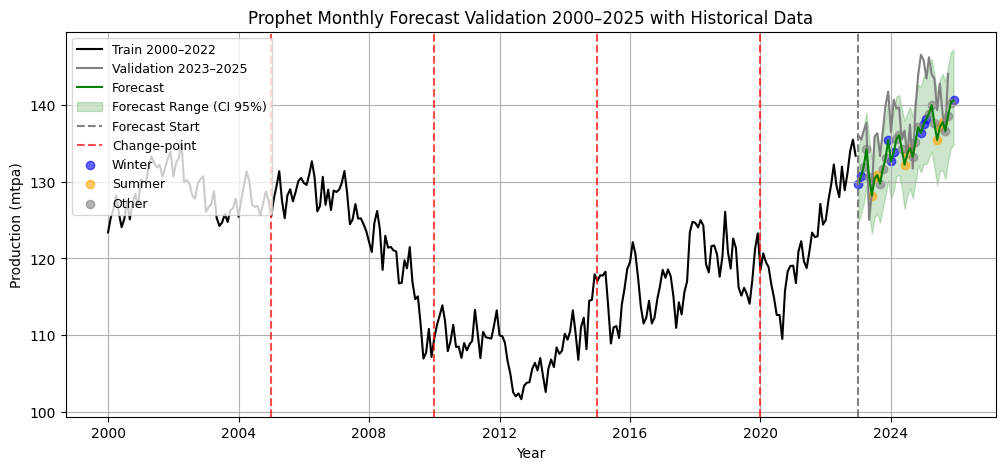

In [0]:
plt.figure(figsize=(12,5))

# Historical Train
plt.plot(train_prophet['ds'], train_prophet['y'], color="black", label="Train 2000–2022")
# Validation actual
plt.plot(valid_prophet['ds'], valid_prophet['y'], color="gray", label="Validation 2023–2025")
# Forecast mean
plt.plot(forecast_valid['ds'], forecast_valid['yhat'], color="green", label="Forecast")
# Fan chart: 95% CI
plt.fill_between(forecast_valid['ds'], forecast_valid['yhat_lower'], forecast_valid['yhat_upper'], 
                 color="green", alpha=0.2, label="Forecast Range (CI 95%)")
# Forecast start
plt.axvline(pd.to_datetime("2022-12-31"), linestyle="--", color='gray', label="Forecast Start")

# Changepoints
for i, cp in enumerate(changepoints):
    plt.axvline(cp, color="red", linestyle="--", alpha=0.7, label="Change-point" if i==0 else None)
    
# Seasonal scatter by group
for season, color in zip(['Winter','Summer','Other'], ['blue','orange','gray']):
    subset = forecast_valid[forecast_valid['Season']==season]
    plt.scatter(subset['ds'], subset['yhat'], color=color, alpha=0.6, label=season)

plt.xlabel("Year")
plt.ylabel("Production (mtpa)")
plt.title("Prophet Monthly Forecast Validation 2000–2025 with Historical Data")
plt.grid(True)

# Drop duplicate legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="upper left", fontsize=9)
plt.show()

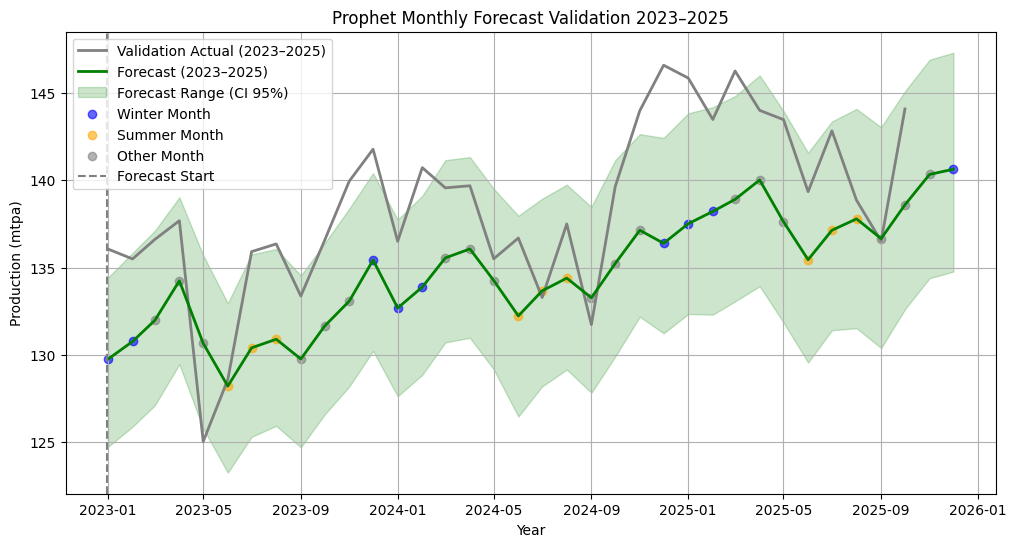

In [0]:
plt.figure(figsize=(12,6))

# Validation actual
plt.plot(
    valid_prophet['ds'], 
    valid_prophet['y'], 
    color="gray", 
    linewidth=2, 
    label="Validation Actual (2023–2025)"
)

# Forecast mean for validation period (2023–2025)
plt.plot(
    forecast_valid['ds'], 
    forecast_valid['yhat'], 
    color="green", 
    linewidth=2, 
    label="Forecast (2023–2025)"
)

# Fan chart = 95% CI
plt.fill_between(
    forecast_valid['ds'], 
    forecast_valid['yhat_lower'], 
    forecast_valid['yhat_upper'], 
    color="green", 
    alpha=0.2, 
    label="Forecast Range (CI 95%)"
)

# Changepoints
for i, cp in enumerate(changepoints):
    cp_date = pd.Timestamp(f"{cp}-01-01").tz_localize(None)
    if pd.Timestamp("2023-01-01") <= cp_date <= pd.Timestamp("2025-12-31"):
        plt.axvline(cp_date, color="red", linestyle="--", alpha=0.7,
                    label="Change-point" if i==0 else None)

# Seasonal scatter
season_colors = {'Winter':'blue','Summer':'orange','Other':'gray'}
for season, color in season_colors.items():
    subset = forecast_valid[forecast_valid['Season']==season]
    plt.scatter(
        subset['ds'], 
        subset['yhat'], 
        color=color, 
        alpha=0.6, 
        label=f"{season} Month"
    )

# Forecast start marker
plt.axvline(pd.to_datetime("2022-12-31"), linestyle="--", color='gray', label="Forecast Start")

plt.xlabel("Year")
plt.ylabel("Production (mtpa)")
plt.title("Prophet Monthly Forecast Validation 2023–2025")
plt.grid(True)

# Clean legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="upper left", fontsize=10)

plt.show()


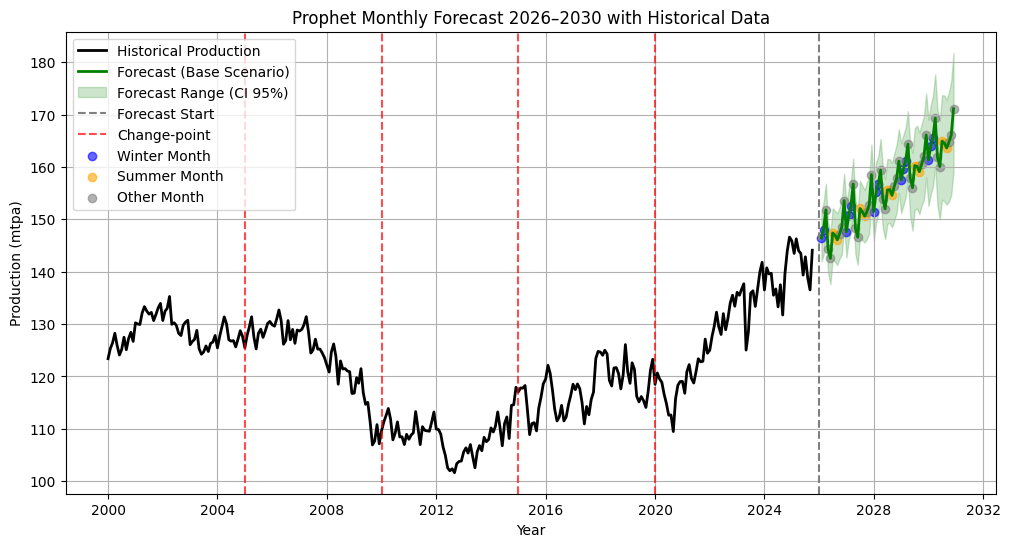

In [0]:
plt.figure(figsize=(12,6))

# Historical
plt.plot(df_canada_prophet['ds'], df_canada_prophet['y'], color="black", linewidth=2, label="Historical Production")

# Forecast mean (Base Scenario)
plt.plot(forecast_26_30['ds'], forecast_26_30['yhat'], color="green", linewidth=2, label="Forecast (Base Scenario)")

# Fan chart = 95% CI (Low / High Scenario)
plt.fill_between(
    forecast_26_30['ds'], 
    forecast_26_30['yhat_lower'], 
    forecast_26_30['yhat_upper'], 
    color="green", alpha=0.2, label="Forecast Range (CI 95%)"
)

# Forecast start
plt.axvline(pd.to_datetime("2025-12-31"), linestyle="--", color='gray', label="Forecast Start")

# Changepoints
for i, cp in enumerate(changepoints):
    plt.axvline(cp, color="red", linestyle="--", alpha=0.7, label="Change-point" if i==0 else None)

# Seasonal scatter
season_colors = {'Winter':'blue','Summer':'orange','Other':'gray'}
for season, color in season_colors.items():
    subset = forecast_26_30[forecast_26_30['Season']==season]
    plt.scatter(subset['ds'], subset['yhat'], color=color, alpha=0.6, label=f"{season} Month")

plt.xlabel("Year")
plt.ylabel("Production (mtpa)")
plt.title("Prophet Monthly Forecast 2026–2030 with Historical Data")
plt.grid(True)

# Drop duplicate legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="upper left", fontsize=10)

plt.show()

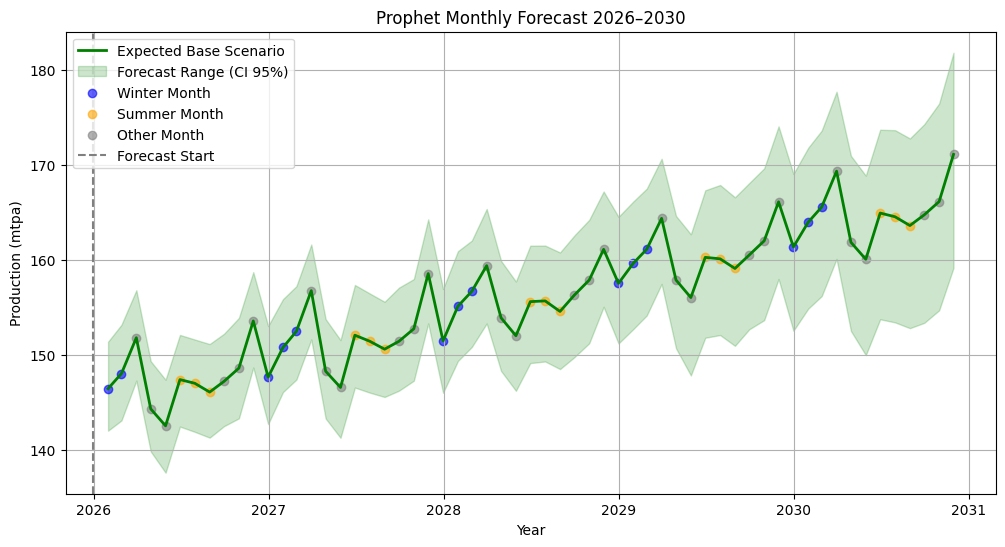

In [0]:
plt.figure(figsize=(12,6))

# Forecast mean (Base Scenario)
plt.plot(
    forecast_26_30['ds'], 
    forecast_26_30['yhat'], 
    color="green", 
    linewidth=2, 
    label="Expected Base Scenario"
)

# Fan chart = 95% CI
plt.fill_between(
    forecast_26_30['ds'], 
    forecast_26_30['yhat_lower'], 
    forecast_26_30['yhat_upper'], 
    color="green", alpha=0.2, 
    label="Forecast Range (CI 95%)"
)

# Changepoints
for i, cp in enumerate(changepoints):
    cp_date = pd.Timestamp(f"{cp}-01-01").tz_localize(None)
    if pd.Timestamp("2023-01-01") <= cp_date <= pd.Timestamp("2025-12-31"):
        plt.axvline(cp_date, color="red", linestyle="--", alpha=0.7,
                    label="Change-point" if i==0 else None)

# Seasonal scatter
season_colors = {'Winter':'blue','Summer':'orange','Other':'gray'}
for season, color in season_colors.items():
    subset = forecast_26_30[forecast_26_30['Season']==season]
    plt.scatter(subset['ds'], subset['yhat'], color=color, alpha=0.6, label=f"{season} Month")

# Forecast start marker
plt.axvline(pd.to_datetime("2025-12-31").date(), linestyle="--", color='gray', label="Forecast Start")

plt.xlabel("Year")
plt.ylabel("Production (mtpa)")
plt.title("Prophet Monthly Forecast 2026–2030")
plt.grid(True)

# Clean legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="upper left", fontsize=10)

plt.show()


###  SARIMA

In [0]:
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort
df = df.sort_values('Date')

# Set index
df = df.set_index('Date')

# Remain target
ts = df['Production_mtpa']

In [0]:
train = ts['2000':'2022']
valid = ts['2023':'2025']

In [0]:
model_train = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_train = model_train.fit()
print(result_train.summary())

/databricks/python/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                    Production_mtpa   No. Observations:                  276
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -516.966
Date:                            Wed, 01 Apr 2026   AIC                           1043.932
Time:                                    05:46:02   BIC                           1061.519
Sample:                                01-01-2000   HQIC                          1051.011
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0711      0.246     -0.289      0.773      -0.554       0.411
ma.L1         -0.1575      0.245   

In [0]:
forecast_valid = result_train.get_forecast(steps=len(valid))

forecast_valid_mean = forecast_valid.predicted_mean
forecast_valid_ci = forecast_valid.conf_int()

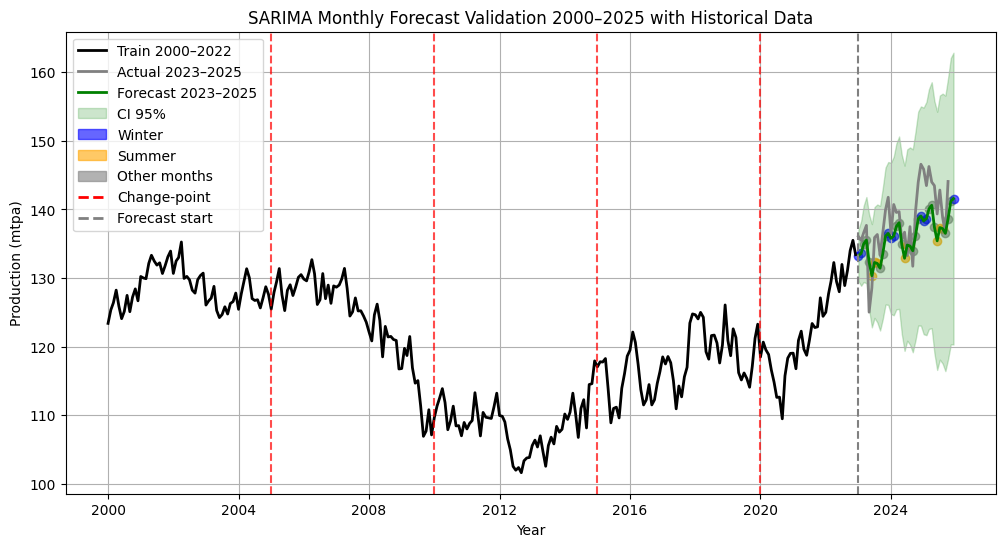

In [0]:
plt.figure(figsize=(12,6))

# --- Train line ---
plt.plot(train.index, train, color='black', linewidth=2, label='Train 2000–2022')

# --- Actual line (no scatter) ---
plt.plot(valid.index, valid, color='gray', linewidth=2, label='Actual 2023–2025')

# --- Forecast line + scatter ---
plt.plot(forecast_valid_mean.index, forecast_valid_mean, color='green', linewidth=2, label='Forecast 2023–2025')
# Scatter only on forecast
for idx, val in enumerate(forecast_valid_mean.index):
    month = val.month
    y_val = forecast_valid_mean.iloc[idx]
    if month in [12,1,2]:
        plt.scatter(val, y_val, color='blue', alpha=0.6)
    elif month in [6,7,8]:
        plt.scatter(val, y_val, color='orange', alpha=0.6)
    else:
        plt.scatter(val, y_val, color='gray', alpha=0.6)

# --- Confidence interval ---
plt.fill_between(forecast_valid_ci.index,
                 forecast_valid_ci.iloc[:,0],
                 forecast_valid_ci.iloc[:,1],
                 color='green', alpha=0.2, label='CI 95%')

# --- Changepoints ---
for i, cp in enumerate(changepoints):
    cp_date = pd.Timestamp(f"{cp}-01-01").tz_localize(None)
    plt.axvline(cp_date, color='red', linestyle='--', alpha=0.7,
                label='Change-point' if i==0 else None)

# --- Forecast start marker ---
plt.axvline(pd.Timestamp("2023-01-01"), linestyle="--", color='gray', label="Forecast start")

# --- Custom legend ---
legend_elements = [
    Line2D([0],[0], color='black', lw=2, label='Train 2000–2022'),
    Line2D([0],[0], color='gray', lw=2, label='Actual 2023–2025'),
    Line2D([0],[0], color='green', lw=2, label='Forecast 2023–2025'),
    Patch(alpha=0.2, color='green', label='CI 95%'),
    Patch(color='blue', alpha=0.6, label='Winter'),
    Patch(color='orange', alpha=0.6, label='Summer'),
    Patch(color='gray', alpha=0.6, label='Other months'),
    Line2D([0],[0], color='red', lw=2, linestyle='--', label='Change-point'),
    Line2D([0],[0], color='gray', lw=2, linestyle='--', label='Forecast start')
]

plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.xlabel("Year")
plt.ylabel("Production (mtpa)")
plt.title("SARIMA Monthly Forecast Validation 2000–2025 with Historical Data")
plt.grid(True)
plt.show()

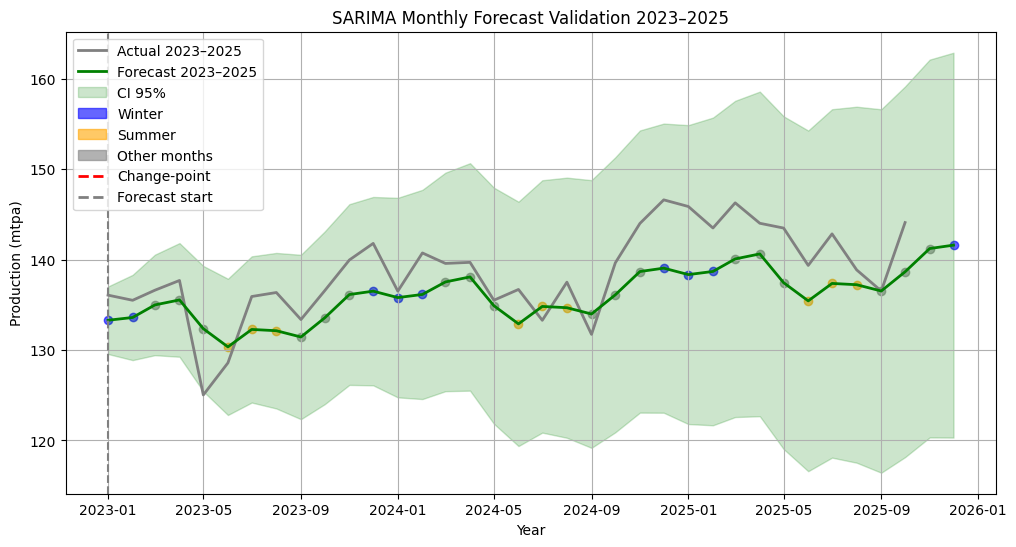

In [0]:
plt.figure(figsize=(12,6))

# --- Actual line (no scatter) ---
plt.plot(valid.index, valid, color='gray', lw=2, label='Actual 2023–2025')

# --- Forecast line + scatter ---
plt.plot(forecast_valid_mean.index, forecast_valid_mean, color='green', lw=2, label='Forecast 2023–2025')
# Scatter only on forecast
for idx, val in enumerate(forecast_valid_mean.index):
    month = val.month
    y_val = forecast_valid_mean.iloc[idx]
    if month in [12,1,2]:
        plt.scatter(val, y_val, color='blue', alpha=0.6)
    elif month in [6,7,8]:
        plt.scatter(val, y_val, color='orange', alpha=0.6)
    else:
        plt.scatter(val, y_val, color='gray', alpha=0.6)

# --- Confidence interval ---
plt.fill_between(forecast_valid_ci.index,
                 forecast_valid_ci.iloc[:,0],
                 forecast_valid_ci.iloc[:,1],
                 color='green', alpha=0.2, label='CI 95%')

# --- Changepoints ---
for i, cp in enumerate(changepoints):
    cp_date = pd.Timestamp(f"{cp}-01-01").tz_localize(None)
    if pd.Timestamp("2023-01-01") <= cp_date <= pd.Timestamp("2025-12-31"):
        plt.axvline(cp_date, color='red', linestyle='--', alpha=0.7,
                    label='Change-point' if i==0 else None)

# --- Forecast start marker ---
plt.axvline(pd.Timestamp("2023-01-01"), linestyle="--", color='gray', label="Forecast start")

# --- Custom legend ---
legend_elements = [
    Line2D([0],[0], color='gray', lw=2, label='Actual 2023–2025'),
    Line2D([0],[0], color='green', lw=2, label='Forecast 2023–2025'),
    Patch(alpha=0.2, color='green', label='CI 95%'),
    Patch(color='blue', alpha=0.6, label='Winter'),
    Patch(color='orange', alpha=0.6, label='Summer'),
    Patch(color='gray', alpha=0.6, label='Other months'),
    Line2D([0],[0], color='red', lw=2, linestyle='--', label='Change-point'),
    Line2D([0],[0], color='gray', lw=2, linestyle='--', label='Forecast start')
]

plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.xlabel("Year")
plt.ylabel("Production (mtpa)")
plt.title("SARIMA Monthly Forecast Validation 2023–2025")
plt.grid(True)
plt.show()

In [0]:
model_full = SARIMAX(
    ts,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

result_full = model_full.fit()

/databricks/python/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/databricks/python/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [0]:
forecast_future = result_full.get_forecast(steps=60)

forecast_future_mean = forecast_future.predicted_mean
forecast_future_ci = forecast_future.conf_int()

# =========================
# SAVE SARIMA FULL FORECAST
# =========================
sarima_full = forecast_future_mean.to_frame(name="yhat")
sarima_full["ds"] = sarima_full.index

ci = forecast_future_ci.copy()
ci.columns = ["yhat_lower", "yhat_upper"]

sarima_full = sarima_full.merge(ci, left_index=True, right_index=True)

sarima_full.reset_index(drop=True, inplace=True)

sarima_full.to_csv(
    f"{BASE_PATH}/data/processed/app_data/sarima_full.csv",
    index=False
)

print("✅ sarima_full.csv saved")

✅ sarima_full.csv saved


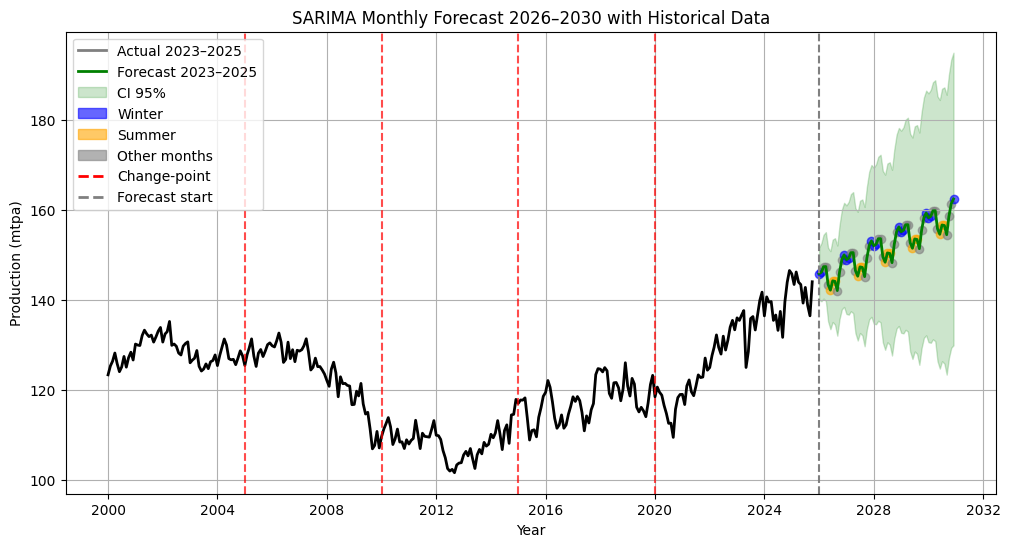

In [0]:
plt.figure(figsize=(12,6))

plt.plot(ts.index, ts, color='black', lw=2, label='Historical 2000–2025')
plt.plot(forecast_future_mean.index, forecast_future_mean, color='green', lw=2, label='Forecast 2026–2030')
plt.fill_between(forecast_future_ci.index,
                 forecast_future_ci.iloc[:,0],
                 forecast_future_ci.iloc[:,1],
                 color='green', alpha=0.2, label='Confidence interval')

# Seasonal scatter (future)
for idx, val in enumerate(forecast_future_mean.index):
    month = val.month
    if month in [12,1,2]:
        plt.scatter(val, forecast_future_mean.iloc[idx], color='blue', alpha=0.6)
    elif month in [6,7,8]:
        plt.scatter(val, forecast_future_mean.iloc[idx], color='orange', alpha=0.6)
    else:
        plt.scatter(val, forecast_future_mean.iloc[idx], color='gray', alpha=0.6)

for cp in changepoints:
    plt.axvline(pd.Timestamp(f"{cp}-01-01"), color='red', linestyle='--', alpha=0.7)

plt.axvline(pd.Timestamp("2026-01-01"), linestyle="--", color='gray', label="Forecast start")

plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.xlabel("Year")
plt.ylabel("Production (mtpa)")
plt.title("SARIMA Monthly Forecast 2026–2030 with Historical Data")
plt.grid(True)
plt.show()

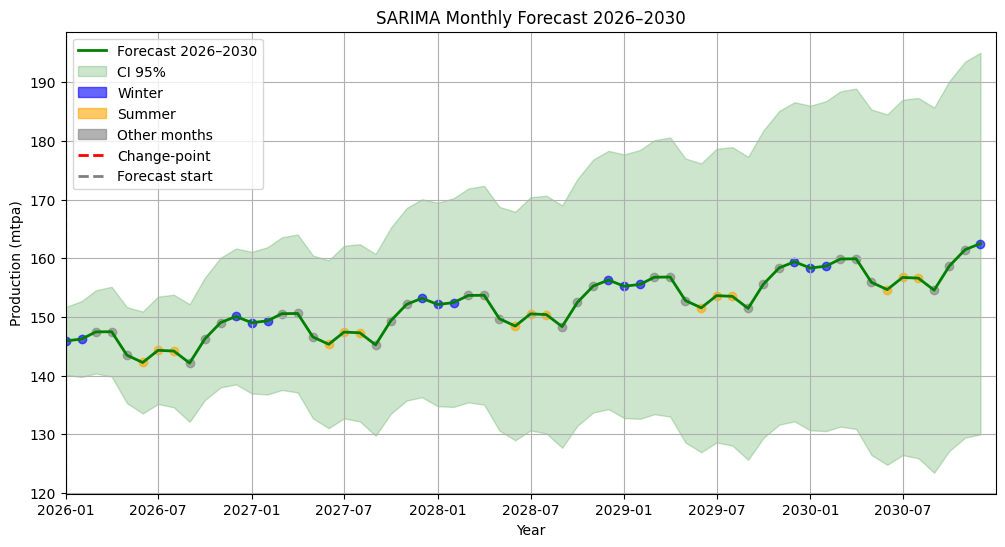

In [0]:
plt.figure(figsize=(12,6))

# Zoom: limit x-axis to 2026–2030
plt.xlim(pd.Timestamp("2026-01-01"), pd.Timestamp("2030-12-31"))

# Forecast line + scatter
plt.plot(forecast_future_mean.index, forecast_future_mean, color='green', lw=2, label='Forecast 2026–2030')

# Confidence interval
plt.fill_between(forecast_future_ci.index,
                 forecast_future_ci.iloc[:,0],
                 forecast_future_ci.iloc[:,1],
                 color='green', alpha=0.2, label='CI 95%')

# Seasonal scatter
for idx, val in enumerate(forecast_future_mean.index):
    month = val.month
    y_val = forecast_future_mean.iloc[idx]
    if month in [12,1,2]:
        plt.scatter(val, y_val, color='blue', alpha=0.6)
    elif month in [6,7,8]:
        plt.scatter(val, y_val, color='orange', alpha=0.6)
    else:
        plt.scatter(val, y_val, color='gray', alpha=0.6)

# Changepoints
for i, cp in enumerate(changepoints):
    cp_date = pd.Timestamp(f"{cp}-01-01").tz_localize(None)
    if pd.Timestamp("2026-01-01") <= cp_date <= pd.Timestamp("2030-12-31"):
        plt.axvline(cp_date, color='red', linestyle='--', alpha=0.7,
                    label='Change-point' if i==0 else None)

# Forecast start marker
plt.axvline(pd.Timestamp("2026-01-01"), linestyle='--', color='gray', label='Forecast start')

# Custom legend
legend_elements = [
    Line2D([0],[0], color='green', lw=2, label='Forecast 2026–2030'),
    Patch(alpha=0.2, color='green', label='CI 95%'),
    Patch(color='blue', alpha=0.6, label='Winter'),
    Patch(color='orange', alpha=0.6, label='Summer'),
    Patch(color='gray', alpha=0.6, label='Other months'),
    Line2D([0],[0], color='red', lw=2, linestyle='--', label='Change-point'),
    Line2D([0],[0], color='gray', lw=2, linestyle='--', label='Forecast start')
]

plt.legend(handles=legend_elements, loc='upper left', fontsize=10)
plt.xlabel("Year")
plt.ylabel("Production (mtpa)")
plt.title("SARIMA Monthly Forecast 2026–2030")
plt.grid(True)
plt.show()

In [0]:
# 2025 baseline (annual average)
baseline_2025 = ts['2025'].mean()
print("2025 Baseline Production (mtpa):", baseline_2025)

2025 Baseline Production (mtpa): 142.47441207499998


In [0]:
# Convert monthly forecast to annual average
forecast_future_df = forecast_future_mean.to_frame(name="Forecast_mtpa")
forecast_future_df["Year"] = forecast_future_df.index.year

annual_forecast = forecast_future_df.groupby("Year")["Forecast_mtpa"].mean().reset_index()

# Keep only 2026–2030
annual_forecast = annual_forecast[(annual_forecast["Year"] >= 2026) & 
                                  (annual_forecast["Year"] <= 2030)].copy()

annual_forecast.head()

,Year,Forecast_mtpa
0,2026,145.725011
1,2027,148.832287
2,2028,151.939581
3,2029,155.046874
4,2030,158.154168


In [0]:
annual_forecast["Incremental_Supply"] = annual_forecast["Forecast_mtpa"] - baseline_2025

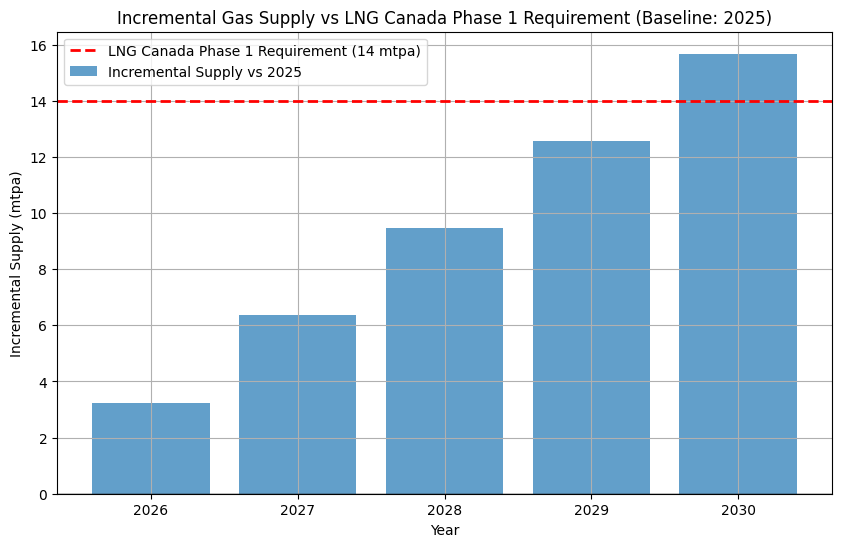

In [0]:
LNG_PHASE1_MTPA = 14

plt.figure(figsize=(10,6))

# Bar: incremental supply
plt.bar(
    annual_forecast["Year"],
    annual_forecast["Incremental_Supply"],
    alpha=0.7,
    label="Incremental Supply vs 2025"
)

# LNG demand line
plt.axhline(
    LNG_PHASE1_MTPA,
    color="red",
    linestyle="--",
    linewidth=2,
    label="LNG Canada Phase 1 Requirement (14 mtpa)"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("Incremental Gas Supply vs LNG Canada Phase 1 Requirement (Baseline: 2025)")
plt.xlabel("Year")
plt.ylabel("Incremental Supply (mtpa)")
plt.legend()
plt.grid(True)
plt.show()

In [0]:
annual_forecast["Supply_Gap"] = annual_forecast["Incremental_Supply"] - LNG_PHASE1_MTPA

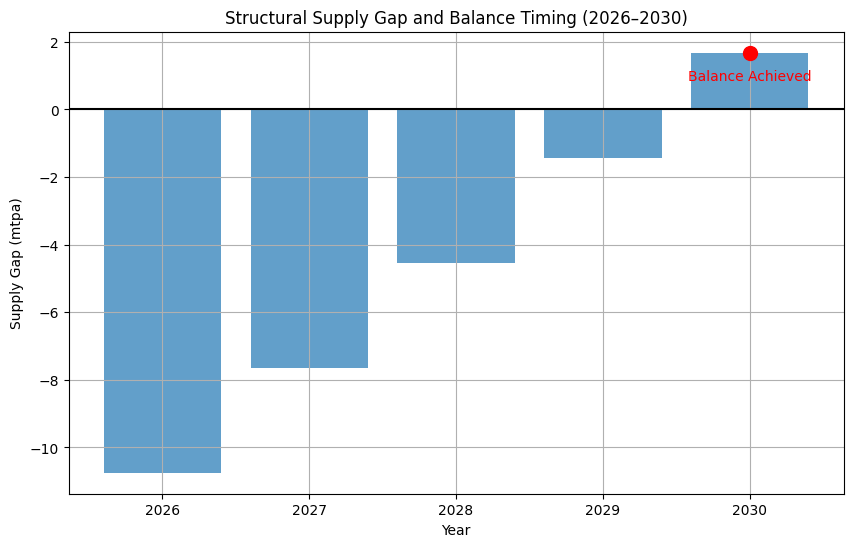

In [0]:
plt.figure(figsize=(10,6))

# Bar plot
plt.bar(annual_forecast["Year"], annual_forecast["Supply_Gap"], alpha=0.7)

# Zero line
plt.axhline(0, color="black", linewidth=1.5)

# ---- Find first positive year ----
cross_year = annual_forecast[annual_forecast["Supply_Gap"] > 0]["Year"].min()

if pd.notna(cross_year):
    cross_value = annual_forecast.loc[
        annual_forecast["Year"] == cross_year, "Supply_Gap"
    ].values[0]
    
    plt.scatter(cross_year, cross_value, color="red", s=100, zorder=5)
    
    plt.annotate(
        f"Balance Achieved",
        (cross_year, cross_value),
        textcoords="offset points",
        xytext=(0,-20),
        ha='center',
        fontsize=10,
        color="red"
    )

plt.title("Structural Supply Gap and Balance Timing (2026–2030)")
plt.xlabel("Year")
plt.ylabel("Supply Gap (mtpa)")
plt.grid(True)
plt.show()